# ĐỌC DỮ LIỆU

In [ ]:
#import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#link và đọc data
link='https://drive.google.com/file/d/1mrmduoD2mmufa2YF_z7Cg2HaJidDfKKd/view?usp=drive_link'
path = 'https://drive.google.com/uc?export=download&id='+link.split('/')[-2]
df = pd.read_csv(path)

In [ ]:
#Xem thông tin cơ bản của dữ liệu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [ ]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# Kiểm tra dữ liệu ở các cột
df.isnull().sum()

,0
customer_id,0
credit_score,0
country,0
gender,0
age,0
tenure,0
balance,0
products_number,0
credit_card,0
active_member,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['country'].value_counts()

,count
country,
France,5014
Germany,2509
Spain,2477


In [ ]:
df['gender'].value_counts()

,count
gender,
Male,5457
Female,4543


In [ ]:
df['age'].value_counts()

,count
age,
37,478
38,477
35,474
36,456
34,447
...,...
84,2
82,1
88,1


In [ ]:
df['tenure'].value_counts()

,count
tenure,
2,1048
1,1035
7,1028
8,1025
5,1012
3,1009
4,989
9,984
6,967


In [ ]:
df[df['estimated_salary'] <0]

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn


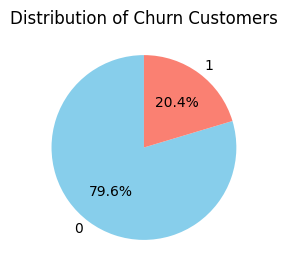

In [ ]:
# Đếm số lần xuất hiện của mỗi giá trị cột 'Churn'
churn_counts = df['churn'].value_counts()

# vẽ sự phân phối 2 giá trị qua pie chart
plt.figure(figsize=(3, 3))
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'])
plt.title('Distribution of Churn Customers')
plt.show()

Dữ liệu bị mất cân bằng (Imbalanced Data).
Cụ thể, tỷ lệ khách hàng rời bỏ (Churn = 1) chỉ chiếm 20.4%, trong khi nhóm ở lại (Churn = 0) chiếm tới 79.6%; điều này có thể sẽ gây ra một số ảnh hưởng đến việc huấn luyện mô hình.
Sẽ tiến hành train model trước và sau khi xử lý mất cân bằng để so sánh.

# BIỂU ĐỒ PHÂN PHỐI CÁC BIẾN NUMERICAL

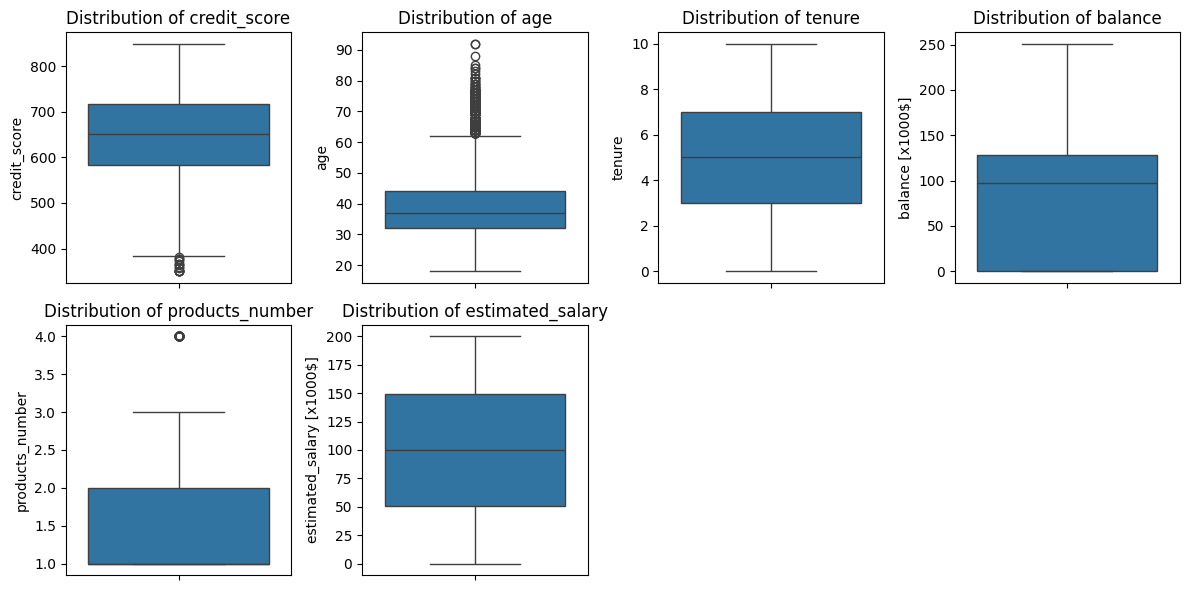

In [ ]:
num_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']

plt.figure(figsize=(12, 6))
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i + 1)
    if col in ['balance', 'estimated_salary']:
      sns.boxplot(df[col]/1000)
      plt.ylabel(f'{col} [x1000$]')
    else:
      sns.boxplot(df[col])
      plt.ylabel(col)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

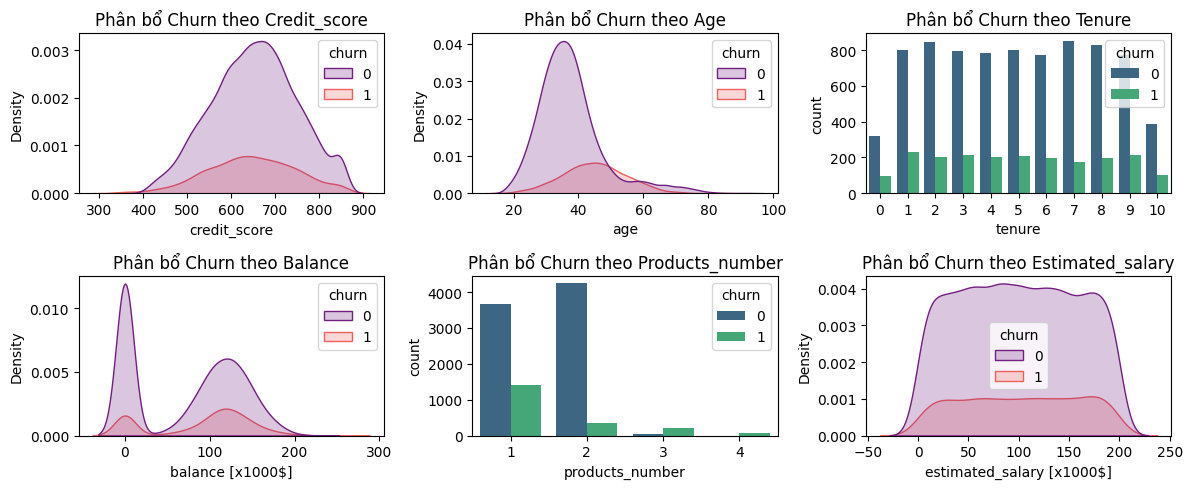

In [ ]:
# Vẽ biểu đồ các biến Numerical phân phối theo Churn
num_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']
# Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 5)) # 2 rows, 3 columns

for i, col in enumerate(num_cols):
    row = i // 3
    col_idx = i % 3

    # Với các cột có ít giá trị duy nhất, vẽ Countplot sẽ rõ hơn
    if col in ['products_number', 'tenure']:
        sns.countplot(x=df[col], hue='churn', data=df, ax=axes[row, col_idx], palette='viridis')
        axes[row, col_idx].set_title(f'Phân bổ Churn theo {col.capitalize()}')

    # Với các cột có dải số rộng, vẽ KDE Plot để xem mật độ phân bổ
    elif col in ['balance', 'estimated_salary']:
        sns.kdeplot(data=df, x=df[col]/1000, hue='churn', fill=True, ax=axes[row, col_idx], palette='magma')
        axes[row, col_idx].set_title(f'Phân bổ Churn theo {col.capitalize()}')
        axes[row, col_idx].set_xlabel(f'{col} [x1000$]')
    else:
        sns.kdeplot(data=df, x=df[col], hue='churn', fill=True, ax=axes[row, col_idx], palette='magma')
        axes[row, col_idx].set_title(f'Phân bổ Churn theo {col.capitalize()}')

plt.tight_layout()
plt.show()

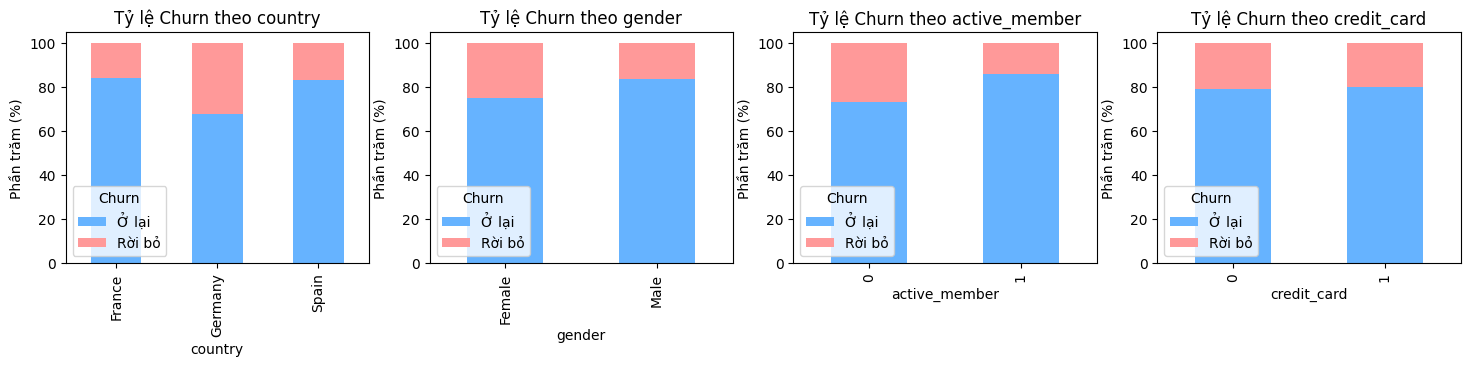

In [ ]:
# Vẽ Stacked Bar Chart của các biến Categorical phân bổ theo Churn
cols_cat = ['country', 'gender', 'active_member', 'credit_card']
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(18, 3))

for i, col in enumerate(cols_cat):
    # Tính tỷ lệ phần trăm
    cross_tab = pd.crosstab(df[col], df['churn'], normalize='index') * 100

    # Vẽ biểu đồ cột chồng
    cross_tab.plot(kind='bar', stacked=True, ax=axes[i], color=['#66b3ff','#ff9999'])
    axes[i].set_title(f'Tỷ lệ Churn theo {col}')
    axes[i].set_ylabel('Phần trăm (%)')
    axes[i].legend(title='Churn', labels=['Ở lại', 'Rời bỏ'])

**Một vài điểm cần lưu ý:**
- Biến Age: Khách hàng trẻ (từ 25 - 40 tuổi) có tỷ lệ Churn cực thấp, từ khoảng 40 - 55 tuổi, tỷ lệ Churn tăng lên đáng kể.
- Biến Products_number: hầu hết KH của ngân hàng này dùng 1-2 sản phẩm, trong đó KH sử dụng 1 hoặc 2 sản phẩm có tỉ lệ rời bỏ thấp nhưng nhóm KH dùng 3 hoặc 4 sản phẩm thì ngược lại, tỉ lệ rời bỏ rất cao và cao hơn KH ở lại.
- Biến Balance: nhóm có Balance = 0 có tỷ lệ KH rời bỏ lại thấp hơn so với nhóm có số dư cao (trong khoảng 100k - 150k).
- Các biến còn lại thì phân bổ theo Churn/ Not churn khá tương đồng với nhau, nhất là estimated_salary gần như phẳng -> ít ảnh hưởng tới việc KH ở lại hay rời bỏ.

# BIỂU ĐỒ PHÂN PHỐI CÁC BIẾN CATEGORICAL

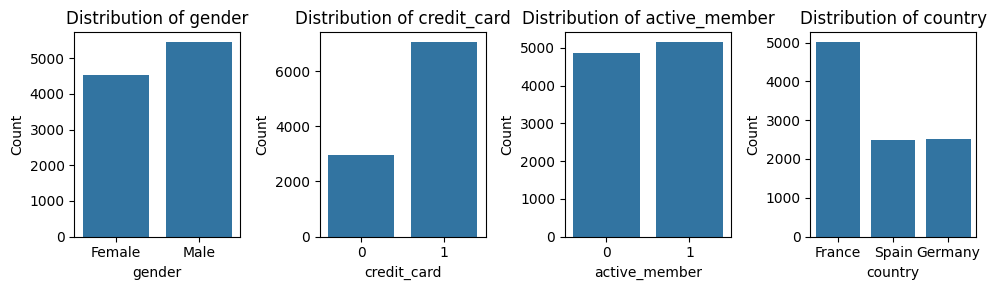

In [ ]:
# Categorical/Binary features
cat_cols = ['gender', 'credit_card', 'active_member', 'country']

plt.figure(figsize=(10, 3))
for i, col in enumerate(cat_cols):
    plt.subplot(1, 4, i + 1) # 1 rows, 4 columns
    sns.countplot(x=df[col])
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Một vài điểm cần lưu ý:**
- Biến Country: trong khi France và Spain có tỷ lệ rời bỏ khá tương đồng (khoảng 18%), thì Germany có tỷ lệ rời bỏ cao vọt (gần gấp đôi hai nước còn lại, xấp xỉ 30-32%) -> Germany là một "điểm đáng lưu tâm".
- Biến Gender: Nữ giới có xu hướng rời bỏ cao hơn (gần gấp đôi) Nam giới.
- Biến Active_member: tín hiệu từ sự tương tác, Nhóm 0 có tỉ lệ rời bỏ cao hơn hẳn so với Nhóm 1.
- Biến Credit_card: hai cột có lệ rời bỏ của người có thẻ tín dụng (1) và người không có thẻ (0) gần như bằng nhau y hệt -> Biến này có khả năng phân loại cực kỳ thấp.

# EDA VÀ CHUẨN HÓA DỮ LIỆU

In [ ]:
# Chuyển Female/Male thành biến 0/1 bằng Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

# Chuyển đổi cột 'country' thành các cột số tương ứng bằng One-Hot Encoding
df = pd.get_dummies(df, columns=['country'], prefix='country', dtype=int)

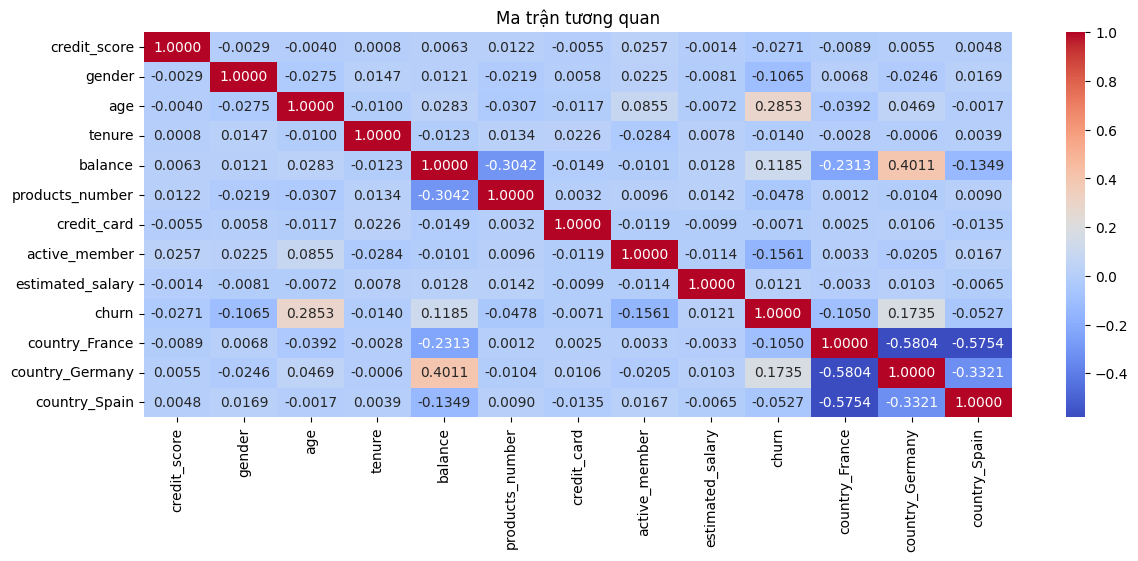

In [ ]:
#Ma trận tương quan
plt.figure(figsize=(14, 5))
sns.heatmap(df.drop(columns=['customer_id']).corr(), annot=True, cmap='coolwarm', fmt='.4f')
plt.title('Ma trận tương quan')
plt.show()

**Nhìn vào ma trận tương quan, nhận thấy:**
- Độ tương quan giữa các thuộc tính với biến mục tiêu tương đối thấp.
- Các thuộc tính tương quan mạnh với biến mục tiêu lần lượt và và giảm dần là "age", "country", "active_member", "balance".
- Thuộc tính "credit_card" tương quan yếu nhất với biến mục tiêu, yếu tiếp theo là "estimated_salary" và "tenure".

In [ ]:
from operator import index
from sklearn.feature_selection import f_classif, SelectKBest

df_drop = df.drop(columns=['customer_id', 'churn'],axis=1)
# Tính toán F-score và P-value
f_scores, p_values = f_classif(df_drop, df['churn'])

# Tạo bảng để so sánh
feature_selection_df = pd.DataFrame({
    'Feature': df_drop.columns,
    'F-Score': f_scores,
    'P-Value': p_values})

# Sắp xếp theo P-value tăng dần (càng nhỏ càng tốt)
feature_selection_df = feature_selection_df.sort_values(by='P-Value')

print(feature_selection_df.to_string(index=False))

         Feature    F-Score       P-Value
             age 886.063275 1.239931e-186
 country_Germany 310.258384  2.059537e-68
   active_member 249.800794  1.348269e-55
         balance 142.473832  1.275563e-32
          gender 114.727989  1.258505e-26
  country_France 111.360517  6.748446e-26
   country_Spain  27.809468  1.366655e-07
 products_number  22.915223  1.717333e-06
    credit_score   7.344522  6.738214e-03
          tenure   1.960164  1.615268e-01
estimated_salary   1.463262  2.264404e-01
     credit_card   0.509401  4.754149e-01


Từ bảng giá trị F-score, P-value của các thuộc tính với biến mục tiêu, ta thấy có 3 thuộc tính gần như khác biệt với các thuộc tính khác là *"credit_card"*, *"estimated_salary"* và *"tenure"*; cũng như từ ma trận tương quan thấy 3 biến này ảnh hưởng rất yếu đến biến mục tiêu.
**Quyết định loại bỏ 3 thuộc tính này khi xây dựng mô hình.**

In [ ]:
# Tạo bảng X và y để train model
X = df.drop(columns=['churn', 'customer_id', 'credit_card', 'estimated_salary', 'tenure'],axis=1)
y = df['churn']

# Chia dữ liệu thành tập train và tập test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42,stratify=y)

In [ ]:
# Scaling một số cột dữ liệu Numerical
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
cols_scaler = ['credit_score','age', 'balance', 'products_number']

X_train_scaler = X_train.copy()
X_test_scaler = X_test.copy()

X_train_scaler[cols_scaler] = std_scaler.fit_transform(X_train[cols_scaler])
X_test_scaler[cols_scaler] = std_scaler.transform(X_test[cols_scaler])

# THỬ NGHIỆM TRAIN MODEL TRÊN DATA TRƯỚC KHI XỬ LÝ IMBALANCE

In [ ]:
# Thực hiện trên 4 model: Logistic Regression, Decision Tree, Random Forest, XGBoost
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report, confusion_matrix


==================== Logistic Regression ====================

Classification Report Logistic Regression:
              precision    recall  f1-score   support

           0       0.83      0.97      0.89      2389
           1       0.65      0.20      0.31       611

    accuracy                           0.81      3000
   macro avg       0.74      0.59      0.60      3000
weighted avg       0.79      0.81      0.77      3000



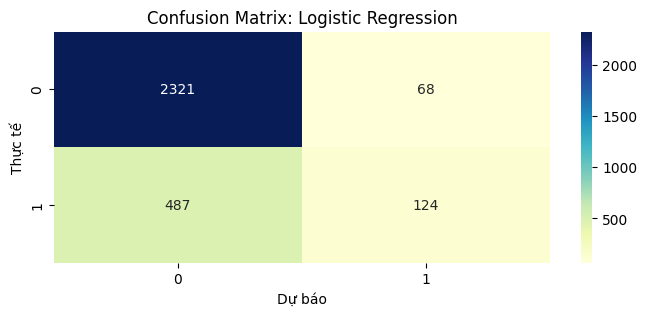


==================== Decision Tree ====================

Classification Report Decision Tree:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      2389
           1       0.77      0.46      0.58       611

    accuracy                           0.86      3000
   macro avg       0.82      0.71      0.75      3000
weighted avg       0.85      0.86      0.85      3000



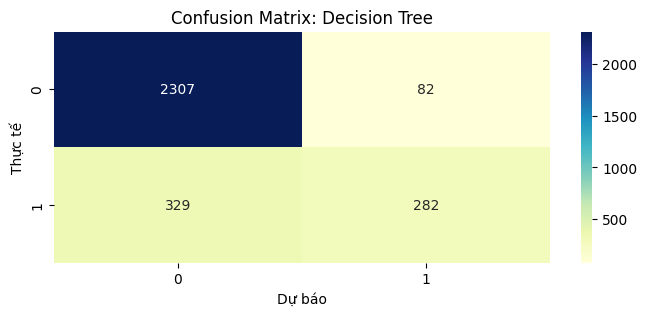


==================== Random Forest ====================

Classification Report Random Forest:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      2389
           1       0.80      0.45      0.57       611

    accuracy                           0.86      3000
   macro avg       0.84      0.71      0.75      3000
weighted avg       0.86      0.86      0.85      3000



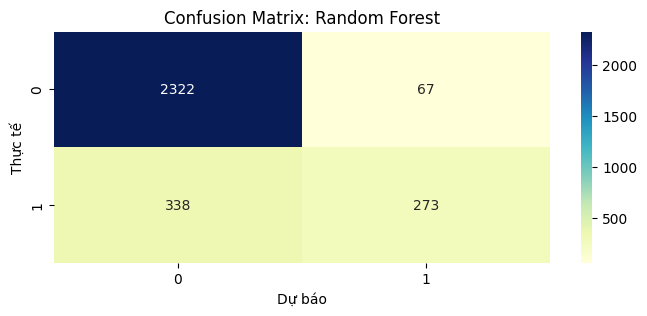


==================== XGBoost ====================

Classification Report XGBoost:
              precision    recall  f1-score   support

           0       0.91      0.86      0.89      2389
           1       0.55      0.69      0.61       611

    accuracy                           0.82      3000
   macro avg       0.73      0.77      0.75      3000
weighted avg       0.84      0.82      0.83      3000



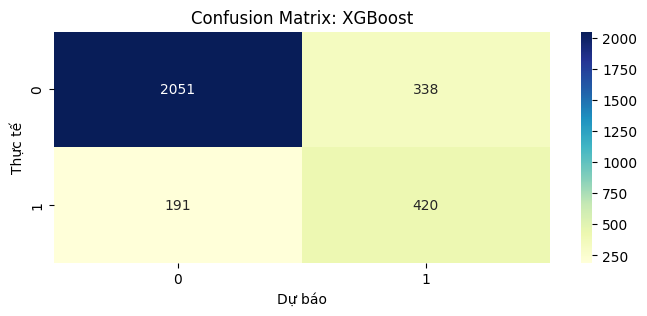


==================== BẢNG TỔNG HỢP KẾT QUẢ TRAINING 4 MODEL ====================
            Mô hình  Acc_Train  Recall_Train  F1_Train  Acc_Test  Recall_Test  F1_Test
Logistic Regression     0.8113        0.1985    0.2999    0.8150       0.2029   0.3088
      Decision Tree     0.8666        0.4509    0.5793    0.8630       0.4615   0.5785
      Random Forest     0.8647        0.4257    0.5618    0.8650       0.4468   0.5741
            XGBoost     0.9416        0.9684    0.8710    0.8237       0.6874   0.6136


In [ ]:
# 1. Khai báo danh sách model
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=6, min_samples_leaf=20, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', scale_pos_weight=4, random_state=42)
}
results = []
# 2. Huấn luyện và Đánh giá
for name, model in models.items():
    # Huấn luyện trên tập đã scale (X_train_scaler)
    model.fit(X_train_scaler, y_train)

    # Dự đoán
    y_pred = model.predict(X_test_scaler)

    # In báo cáo so sánh chi tiết
    results.append({
      "Mô hình": name,
      "Acc_Train": model.score(X_train_scaler, y_train),
      "Recall_Train": recall_score(y_train, model.predict(X_train_scaler)),
      "F1_Train": f1_score(y_train, model.predict(X_train_scaler)),
      "Acc_Test": model.score(X_test_scaler, y_test),
      "Recall_Test": recall_score(y_test, y_pred),
      "F1_Test": f1_score(y_test, y_pred)}
    )
    print(f"\n" + "="*20 + f" {name} " + "="*20)
    print(f"\nClassification Report {name}:")
    print(classification_report(y_test, y_pred))
    cnf_matrix = confusion_matrix(y_test, y_pred)
    # Vẽ Ma trận nhầm lẫn để trực quan hóa kết quả
    plt.figure(figsize=(8,3))
    sns.heatmap(cnf_matrix, annot=True, fmt='d', cmap='YlGnBu')
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Dự báo")
    plt.ylabel("Thực tế")
    plt.show()
df_results = pd.DataFrame(results).round(4)
print("\n" + "="*20 + " BẢNG TỔNG HỢP KẾT QUẢ TRAINING 4 MODEL " + "="*20)
print(df_results.to_string(index=False))

# THỬ NGHIỆM TRAIN MODEL TRÊN DATA SAU KHI XỬ LÝ IMBALANCE

In [ ]:
# XỬ LÝ IMBALANCE TRÊN TẬP TRAIN ĐÃ SCAILING (HYBRID)
from imblearn.combine import SMOTEENN
sme = SMOTEENN(random_state=42, sampling_strategy=0.7)
X_train_res, y_train_res = sme.fit_resample(X_train_scaler, y_train)

# Kiểm tra số lượng mẫu sau khi xử lý
print(pd.Series(y_train_res).value_counts(normalize=True))

churn
0    0.590606
1    0.409394
Name: proportion, dtype: float64



==================== Logistic Regression ====================

Classification Report Logistic Regression:
              precision    recall  f1-score   support

           0       0.89      0.79      0.84      2389
           1       0.43      0.63      0.51       611

    accuracy                           0.76      3000
   macro avg       0.66      0.71      0.67      3000
weighted avg       0.80      0.76      0.77      3000



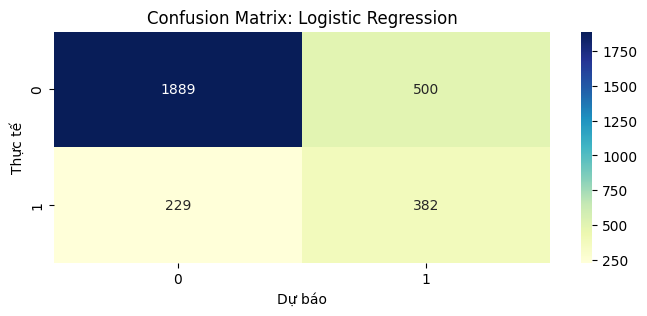


==================== Decision Tree ====================

Classification Report Decision Tree:
              precision    recall  f1-score   support

           0       0.91      0.85      0.88      2389
           1       0.54      0.69      0.60       611

    accuracy                           0.82      3000
   macro avg       0.73      0.77      0.74      3000
weighted avg       0.84      0.82      0.82      3000



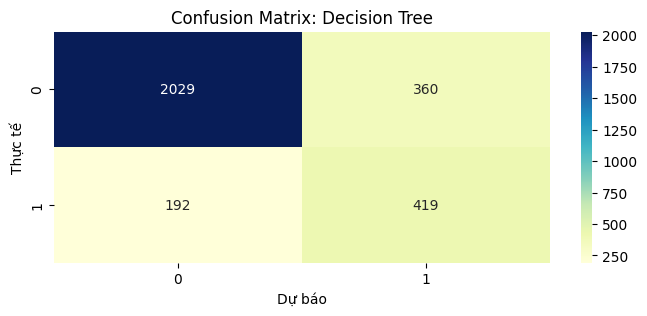


==================== Random Forest ====================

Classification Report Random Forest:
              precision    recall  f1-score   support

           0       0.92      0.86      0.89      2389
           1       0.57      0.71      0.63       611

    accuracy                           0.83      3000
   macro avg       0.74      0.79      0.76      3000
weighted avg       0.85      0.83      0.84      3000



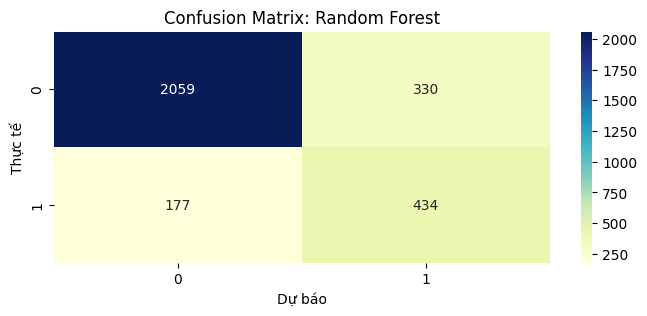


==================== XGBoost ====================

Classification Report XGBoost:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      2389
           1       0.53      0.74      0.62       611

    accuracy                           0.81      3000
   macro avg       0.73      0.79      0.75      3000
weighted avg       0.85      0.81      0.83      3000



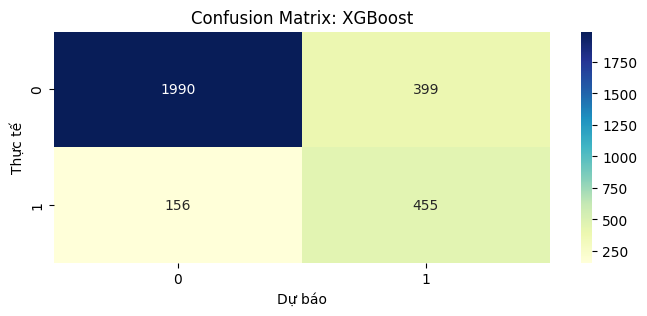


==================== BẢNG TỔNG HỢP KẾT QUẢ TRAINING 4 MODEL SAU KHI RES====================
            Mô hình  Acc_Train  Recall_Train  F1_Train  Acc_Test  Recall_Test  F1_Test
Logistic Regression     0.8075        0.7310    0.7567     0.757       0.6252   0.5117
      Decision Tree     0.9134        0.8508    0.8894     0.816       0.6858   0.6029
      Random Forest     0.9237        0.8740    0.9036     0.831       0.7103   0.6313
            XGBoost     0.9976        1.0000    0.9971     0.815       0.7447   0.6212


In [ ]:
# TRAINING MODEL TRÊN DATASET ĐÃ XỬ LÝ RESAMPLING
# 1. Khai báo danh sách model
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=6, min_samples_leaf=20, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', scale_pos_weight=4, random_state=42)
}
results_res = []
# 2. Huấn luyện và Đánh giá
for name, model in models.items():
    # Huấn luyện trên tập đã scale và resample (X_train_res)
    model.fit(X_train_res, y_train_res)

    # Dự đoán
    y_pred_res = model.predict(X_test_scaler)

    # In báo cáo so sánh chi tiết
    results_res.append({
      "Mô hình": name,
      "Acc_Train": model.score(X_train_res, y_train_res),
      "Recall_Train": recall_score(y_train_res, model.predict(X_train_res)),
      "F1_Train": f1_score(y_train_res, model.predict(X_train_res)),
      "Acc_Test": model.score(X_test_scaler, y_test),
      "Recall_Test": recall_score(y_test, y_pred_res),
      "F1_Test": f1_score(y_test, y_pred_res)}
    )
    print(f"\n" + "="*20 + f" {name} " + "="*20)
    print(f"\nClassification Report {name}:")
    print(classification_report(y_test, y_pred_res))
    cnf_matrix_res = confusion_matrix(y_test, y_pred_res)
    # Vẽ Ma trận nhầm lẫn để trực quan hóa kết quả
    plt.figure(figsize=(8,3))
    sns.heatmap(cnf_matrix_res, annot=True, fmt='d', cmap='YlGnBu')
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Dự báo")
    plt.ylabel("Thực tế")
    plt.show()
df_results_res = pd.DataFrame(results_res).round(4)
print("\n" + "="*20 + " BẢNG TỔNG HỢP KẾT QUẢ TRAINING 4 MODEL SAU KHI RES " + "="*20)
print(df_results_res.to_string(index=False))

**Qua kết quả 2 lần chạy thử nghiệm trên, ta nhận thấy:**
- Trước Resampling: có thể thấy Recall_Test của các model rất thấp (như Logistic chỉ ~0.2, DT hay RF ~0.45) và thấp hơn nhiều so với Acc_Test. Điều này xảy ra vì tập dữ liệu gốc bị lệch (80% không rời đi). Mô hình đoán hầu hết khách hàng sẽ "Ở lại" để giữ Accuracy cao.
- Sau Resampling: Recall_Test tăng lên ngưỡng 0.62 - 0.74 ở các model vì mô hình đã dần học các đặc điểm của nhóm khách hàng rời đi. Đây là bước quan trọng nhất vì mục tiêu của bài toán này là tìm ra được khách Churn.
- Và trong các model chạy thử nghiệm, quyết định chọn Random Forest vì:
  + RF mang lại chỉ số F1-Score cao nhất (0.63) và Acc và Recall không khác biệt quá lớn (0.83-0.71) trên tập Test, đảm bảo sự cân bằng giữa khả năng phát hiện khách rời bỏ và độ chính xác của cảnh báo.
  + Đồng thời, mô hình cho thấy tính ổn định cao hơn, sự chênh lệch điểm giữa tập train và test không quá lớn (tuy XGBoost trên có Acc và Recall trên tập Test (0.815-0.745) cân bằng hơn nhưng trên tập Train lại đạt Acc và Recall gần như tuyệt đối -> có vẻ như bị Overfitting).

# TỐI ƯU HÓA SIÊU THAM SỐ

In [ ]:
!pip install scikit-optimize
from skopt import BayesSearchCV
from sklearn.metrics import f1_score, make_scorer

baye_spaces = {
    'n_estimators': (100, 300),
    'max_depth': (5, 12),
    'min_samples_split': (2, 30),
    'min_samples_leaf': (3, 20),
    'max_features': ['sqrt', 'log2']
  }
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
# Khởi tạo BayesSearchCV
rf_baye = BayesSearchCV(
   estimator=rf,
   search_spaces=baye_spaces,
   cv=5,
   n_iter=32,
   scoring='f1',
   n_jobs=-1)
# Huấn luyện (Sử dụng tập dữ liệu đã Scailing và Resampling)
rf_baye.fit(X_train_res, y_train_res)
# In kết quả
print("\nTHAM SỐ TỐT NHẤT TÌM ĐƯỢC:")
print(rf_baye.best_params_)


THAM SỐ TỐT NHẤT TÌM ĐƯỢC:
OrderedDict({'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 100})


--- KẾT QUẢ TRÊN TẬP TEST (BEST MODEL) ---
              precision    recall  f1-score   support

           0       0.92      0.86      0.89      2389
           1       0.57      0.73      0.64       611

    accuracy                           0.83      3000
   macro avg       0.75      0.79      0.76      3000
weighted avg       0.85      0.83      0.84      3000

Acc: 0.8323
Recall: 0.7250
F1_score: 0.6379


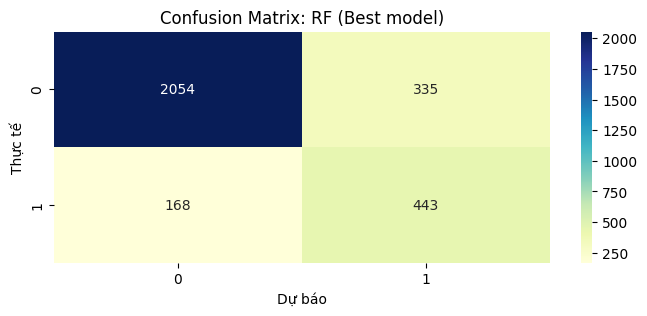

In [ ]:
# Gán model tốt nhất vào để dùng chạy cho tập Test
best_rf = rf_baye.best_estimator_
y_pred_best_rf = best_rf.predict(X_test_scaler)
# In báo cáo chi tiết
print("--- KẾT QUẢ TRÊN TẬP TEST (BEST MODEL) ---")
print(classification_report(y_test, y_pred_best_rf))
print(f"Acc: {best_rf.score(X_test_scaler, y_test):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_best_rf):.4f}")
print(f"F1_score: {f1_score(y_test, y_pred_best_rf):.4f}")
# Vẽ Ma trận nhầm lẫn để trực quan hóa kết quả
cnf_matrix_best = confusion_matrix(y_test, y_pred_best_rf)
plt.figure(figsize=(8,3))
sns.heatmap(cnf_matrix_best, annot=True, fmt='d', cmap='YlGnBu')
plt.title(f"Confusion Matrix: RF (Best model)")
plt.xlabel("Dự báo")
plt.ylabel("Thực tế")
plt.show()


Sau khi tối ưu tham số, có thể nói rằng mô hình đang học có vẻ đang học tốt lên,  ta thấy các chỉ số đều tăng lên nhẹ: Recall (từ 0.7103 lên 0.7250) và Acc (từ 0.831 lên 0.8323), F1_score (từ 0,6313 lên 0.6379).

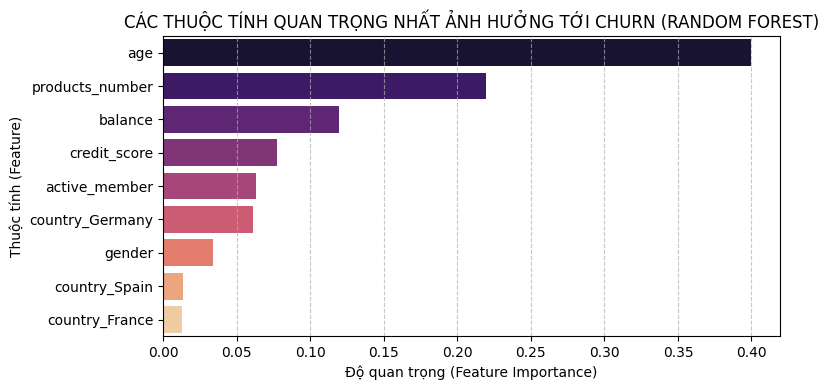

In [ ]:
# Vẽ biểu đồ thể hiện các thuộc tính quan trọng ảnh hưởng tới Churn
feature_imp = best_rf.feature_importances_
feature_names = X_train_res.columns

# Tạo DataFrame cho feature importances
feature_imp = pd.DataFrame({'feature': feature_names, 'importance': feature_imp})
feature_imp = feature_imp.sort_values(by='importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(
    x='importance',
    y='feature',
    data=feature_imp,
    hue='feature',
    palette='magma',
    legend=False)
plt.title('CÁC THUỘC TÍNH QUAN TRỌNG NHẤT ẢNH HƯỞNG TỚI CHURN (RANDOM FOREST)')
plt.xlabel('Độ quan trọng (Feature Importance)')
plt.ylabel('Thuộc tính (Feature)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# SUMMARY

1. Dự đoán một số nguyên nhân:
Ta thấy các thuộc tính Age (~ 40%), Products_number (~ 22%) và Balance (~ 12%) đang là các yếu tố ảnh hưởng nhiều tới việc KH Churn:
- Theo biểu đồ phân phối Churn theo Age phía trên thì phần lớn KH churn là KH lớn tuổi nằm (từ 40-55), đối tượng này có một lượng tích lũy tài sản và yêu cầu cao về dịch vụ. Họ dễ rời bỏ nếu cảm thấy không được chăm sóc ưu tiên, lãi suất không tốt, ... thì họ có khả năng chuyển sang các ngân hàng khác có dịch vụ hậu mãi tốt, hấp dẫn hơn.
- KH chỉ mở TKTT mà không dùng thẻ tín dụng, tiền gửi tiết kiệm hoặc một dịch vụ nào khác của ngân hàng thì độ "trung thành" của họ khá thấp vì không có sự ràng buộc chặt chẽ về mặt tài chính với ngân hàng, họ dễ rời đi nếu chỉ cần một đối thủ có lãi suất tiền gửi, dịch vụ ưu đãi/ tiện ích tốt hơn.
- Balance: rời đi có thể cảm thấy vì không nhận được giá trị xứng đáng với số tiền họ gửi (số dư cao) hoặc để tìm kiếm các tài khoản không yêu cầu duy trì số dư tối thiểu/ có phí thấp hơn (số dư thấp).
- Ngoài ra, cũng cần lưu tâm đến nhóm KH là người Germany vì nhóm này có tỉ lệ Churn cao hơn rất nhiều so với KH ở Spain và France; có thể do các chính sách dịch vụ, quy định của ngân hàng chưa phù hợp với văn hóa, lối sống của người nước này.
2. Một vài đề xuất:
- Xây dựng các gói dịch vụ, ưu dãi theo từng nhóm Độ tuổi.
- Ưu đãi mở thẻ tín dụng: tặng voucher mua sắm hoặc hoàn tiền ngay khi khách hàng mở thêm thẻ tín dụng và thực hiện giao dịch đầu tiên.
- Miễn phí phí duy trì TKTT khi KH mở TKTK tại ngân hàng với số dư tối thiểu.
- Tìm hiểu kĩ hơn về thói quen tiêu dùng hoặc các quy định tài chính đặc thù tại Đức để tối ưu hóa sản phẩm và dịch vụ tại thị trường Đức.
3. Đề xuất cải thiện và xây dựng mô hình ML để dự đoán chính xác hơn:
- Cho model thực nghiệm nhiều hơn nữa với dữ liệu mới từ database của ngân hàng để có thể nâng cao hiệu suất mô hình tốt hơn.
- Chấm điểm (Scoring): Chạy mô hình best_rf trên dữ liệu mới để tính Xác suất Churn và lên các phương án cải thiện.
- Có thể thử huấn luyện riêng một mô hình chỉ cho dữ liệu khách hàng ở Đức để model có thể học được những đặc điểm riêng của nhóm này và đưa ra dự đoán chính xác hơn.